# 場（競馬場）別の勝率チェック — OOS ロック区間

## 目的
配布モデル（`nar evaluate-final --unlock-oos` で開封済みのロック区間評価）の予測を使い、
場（競馬場）ごとにモデルの1着的中率（＝アンサンブル最上位評価の馬が実際に勝った割合、
以下「勝率」）を確認する。場によって精度に系統的な差があるかを見るのが目的で、
新たに検定に通すための開封は行わない（OOS は施錠区間で、開封は1回で終える運用のため、
既に `artifacts/oos_predictions.parquet` / `artifacts/banei/oos_predictions.parquet` として
永続化済みの行単位予測を読むだけに留める。`nar.eval.final_oos.evaluate` は呼び直さない）。

## データと粒度
- 入力: `../artifacts/oos_predictions.parquet`（トラックA本体、平地13場）、
  `../artifacts/banei/oos_predictions.parquet`（ばんえい、帯広ばのみ）。
  どちらも `nar evaluate-final --unlock-oos` の出力で、`artifacts/oos_access.log` /
  `artifacts/banei/oos_access.log` に開封記録がある。
- 1行 = 1レースの1頭（`race_id` × `horse_no` が主キー）。
- `race_id` は `場コード(2桁) + 開催年月日(8桁) + レース番号(2桁)` の12桁
  （`src/nar/transform/keys.py`）。先頭2桁を `../data_real/meta/track_master.json` で
  場名に変換する。
- [[banei-is-a-separate-model-family]] のとおり、ばんえい（帯広ば）は平地と別モデル系統。
  同じ「勝率」表で並べて比較できる指標ではあるが、**同一プールで多重比較補正はしない**
  （場を跨いだ比較の対象は平地13場のみとし、ばんえいは単独で報告する）。

## 制約（先に明記する）
- この2ファイルには `odds_win` / `popularity` 列が無い（配布物の設計変更で削られた）。
  そのため市場オッズ基準の勝率（人気1番の実際の勝率など）はこのノートブックでは出せない。
  比較対象は「モデルの最上位評価馬」の勝率のみ。
- 場によってレース数・平均頭数が大きく異なる（頭数が多い場ほど1着的中率は構造的に下がる）。
  場間の差を見るときは、この頭数構成の違いを結果と一緒に必ず示す。


In [1]:
import sys
sys.path.insert(0, "../src")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from statsmodels.stats.proportion import proportion_confint

from nar.eval.metrics import benjamini_hochberg, block_bootstrap_ci

pd.set_option("display.width", 120)
ARTIFACTS = "../artifacts"
META = "../data_real/meta"

plt.rcParams["font.family"] = "Noto Sans CJK JP"   # 日本語ラベルの文字化け防止


## 1. データ読み込みと健全性チェック
粒度（1行=1頭1レース）、重複キー、欠損、期間、場ごとの件数をまず確認する。
これを飛ばすと場別集計が何を数えているのか分からなくなる。

In [2]:
track_master = json.load(open(f"{META}/track_master.json", encoding="utf-8"))
code_to_track = {v: k for k, v in track_master.items()}

def load_oos(path: str, label: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    df["baba_code"] = df["race_id"].astype(str).str[:2].astype(int)
    unknown = sorted(set(df["baba_code"]) - set(code_to_track))
    if unknown:
        raise ValueError(f"{label}: track_master.json に無い場コード {unknown}")
    df["track"] = df["baba_code"].map(code_to_track)
    df["field"] = label
    return df

flat = load_oos(f"{ARTIFACTS}/oos_predictions.parquet", "平地")
banei = load_oos(f"{ARTIFACTS}/banei/oos_predictions.parquet", "ばんえい")

for name, df in [("平地", flat), ("ばんえい", banei)]:
    dup = df.duplicated(subset=["race_id", "horse_no"]).sum()
    na = df[["race_id", "horse_no", "race_date", "is_win", "finish_pos",
             "clogit", "lgbm", "tabm", "ensemble"]].isna().mean()
    print(f"=== {name} ===")
    print("shape:", df.shape, "| races:", df["race_id"].nunique())
    print("期間:", df["race_date"].min().date(), "〜", df["race_date"].max().date())
    print("重複キー(race_id, horse_no):", dup)
    print("列ごとの欠損率:\n", na[na > 0] if (na > 0).any() else "欠損なし")
    print()


=== 平地 ===
shape: (357419, 12) | races: 35059
期間: 2024-02-01 〜 2026-09-02
重複キー(race_id, horse_no): 0
列ごとの欠損率:
 欠損なし

=== ばんえい ===
shape: (40906, 12) | races: 4425
期間: 2024-02-03 〜 2026-08-31
重複キー(race_id, horse_no): 0
列ごとの欠損率:
 欠損なし



In [3]:
field_size = flat.groupby("race_id").size()
print("平地: 場ごとのレース数・平均頭数")
race_track = flat.drop_duplicates("race_id").set_index("race_id")["track"]
summary_n = pd.DataFrame({
    "n_races": flat.groupby("track")["race_id"].nunique(),
    "n_rows": flat.groupby("track").size(),
})
summary_n["avg_field_size"] = summary_n["n_rows"] / summary_n["n_races"]
summary_n.sort_values("n_races", ascending=False).round(2)


平地: 場ごとのレース数・平均頭数


,n_races,n_rows,avg_field_size
track,,,
園田,4158,41718,10.03
名古屋,3575,39636,11.09
佐賀,3200,32800,10.25
高知,2955,29156,9.87
大井,2950,35218,11.94
笠松,2680,22779,8.50
門別,2628,26118,9.94
金沢,2605,23141,8.88
水沢,1981,19730,9.96


欠損・重複キーがゼロであること、場コードがすべて `track_master.json` に載っていることを
確認できたら先に進む。頭数は場によって最大2頭近く（表の `avg_field_size` 列）ばらつくため、
後段の勝率差を見るときはこの構成差を割り引いて解釈する。

## 2. 場別の勝率（モデル最上位評価馬の1着的中率）
各レースでアンサンブル確率が最大の馬を「モデルの本命」とし、それが実際に1着になった
割合を場ごとに集計する。信頼区間は Wilson の95%区間（二項比率、行＝レース独立を仮定）。

In [4]:
def top1_hits(df: pd.DataFrame, model_col: str) -> pd.DataFrame:
    d = df[["race_id", "track", "finish_pos", model_col]].copy()
    rank_desc = d.groupby("race_id", sort=False)[model_col].rank(ascending=False, method="first")
    d["hit"] = ((rank_desc == 1) & (d["finish_pos"] == 1)).astype(int)
    return d.groupby("race_id", sort=False).agg(track=("track", "first"), hit=("hit", "max"))

def win_rate_by_track(df: pd.DataFrame, model_col: str) -> pd.DataFrame:
    races = top1_hits(df, model_col)
    rows = []
    for track, g in races.groupby("track"):
        n, k = len(g), int(g["hit"].sum())
        lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
        rows.append(dict(track=track, n_races=n, wins=k, win_rate=k / n, ci_lo=lo, ci_hi=hi))
    return pd.DataFrame(rows).sort_values("win_rate", ascending=False).reset_index(drop=True)

flat_win = win_rate_by_track(flat, "ensemble")
flat_win.round(4)


,track,n_races,wins,win_rate,ci_lo,ci_hi
0,金沢,2605,1063,0.4081,0.3893,0.4271
1,佐賀,3200,1262,0.3944,0.3776,0.4114
2,高知,2955,1165,0.3942,0.3768,0.4120
3,笠松,2680,991,0.3698,0.3517,0.3882
4,門別,2628,969,0.3687,0.3505,0.3873
5,園田,4158,1502,0.3612,0.3468,0.3760
6,大井,2950,1022,0.3464,0.3295,0.3638
7,船橋,1964,676,0.3442,0.3235,0.3655
8,川崎,1927,650,0.3373,0.3165,0.3587
9,名古屋,3575,1186,0.3317,0.3165,0.3474


参考として個別モデル（`clogit` / `lgbm` / `tabm`）と、アンサンブルの全体平均も並べる。

In [5]:
MODEL_COLS = ["clogit", "lgbm", "tabm", "ensemble"]
overall_rows = []
for m in MODEL_COLS:
    races = top1_hits(flat, m)
    n, k = len(races), int(races["hit"].sum())
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    overall_rows.append(dict(model=m, n_races=n, wins=k, win_rate=k / n, ci_lo=lo, ci_hi=hi))
pd.DataFrame(overall_rows).round(4)


,model,n_races,wins,win_rate,ci_lo,ci_hi
0,clogit,35059,11909,0.3397,0.3347,0.3447
1,lgbm,35059,12536,0.3576,0.3526,0.3626
2,tabm,35059,12494,0.3564,0.3514,0.3614
3,ensemble,35059,12510,0.3568,0.3518,0.3619


### 場別グラフ（アンサンブル）
点が全体平均勝率（点線）から離れているほど、その場でモデルの本命がより/より当たらない
ことを示す。誤差線は Wilson 95%CI。

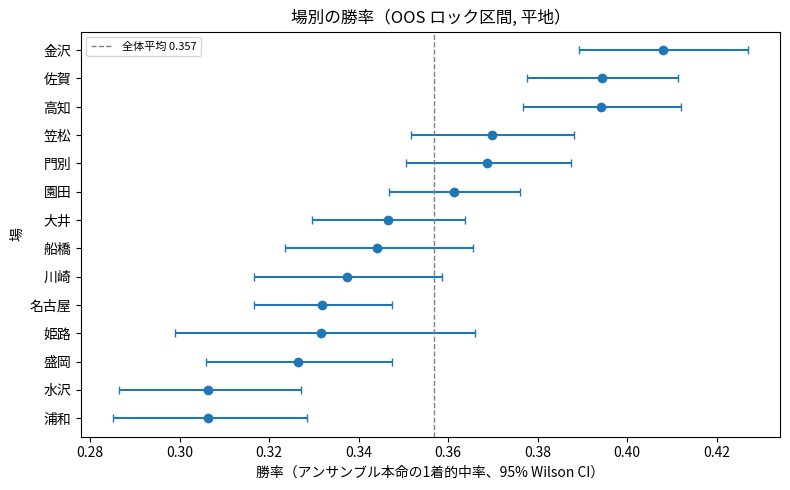

In [6]:
overall_rate = flat_win["wins"].sum() / flat_win["n_races"].sum()

fig, ax = plt.subplots(figsize=(8, 5))
order = flat_win.sort_values("win_rate", ascending=False)
yerr = [order["win_rate"] - order["ci_lo"], order["ci_hi"] - order["win_rate"]]
ax.errorbar(order["win_rate"], order["track"], xerr=yerr, fmt="o", capsize=3)
ax.axvline(overall_rate, color="gray", ls="--", lw=1, label=f"全体平均 {overall_rate:.3f}")
ax.set_xlabel("勝率（アンサンブル本命の1着的中率、95% Wilson CI）")
ax.set_ylabel("場")
ax.set_title("場別の勝率（OOS ロック区間, 平地）")
ax.invert_yaxis()
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("track_win_rate.png", dpi=120)
plt.show()


## 3. 多重比較補正
平地13場について「その場の勝率は全体平均と異なるか」を二項検定で調べる。13件同時に見るので
Benjamini–Hochberg 法で補正する（`~/.claude/CLAUDE.md` の多重比較補正の下限）。

In [7]:
pvals = []
for _, row in flat_win.iterrows():
    pvals.append(binomtest(int(row["wins"]), int(row["n_races"]), overall_rate).pvalue)
flat_win["pval"] = pvals
flat_win["padj_bh"] = benjamini_hochberg(flat_win["pval"].to_numpy())
flat_win["diff_from_overall"] = flat_win["win_rate"] - overall_rate
flat_win["significant_fdr5pct"] = flat_win["padj_bh"] < 0.05

print(f"検定件数: {len(flat_win)}  | 補正前 p<0.05: {(flat_win['pval'] < 0.05).sum()} 件"
      f"  | BH補正後 padj<0.05: {flat_win['significant_fdr5pct'].sum()} 件")
cols = ["track", "n_races", "win_rate", "diff_from_overall", "pval", "padj_bh", "significant_fdr5pct"]
flat_win[cols].sort_values("padj_bh").round(4)


検定件数: 14  | 補正前 p<0.05: 7 件  | BH補正後 padj<0.05: 7 件


,track,n_races,win_rate,diff_from_overall,pval,padj_bh,significant_fdr5pct
0,金沢,2605,0.4081,0.0512,0.0000,0.0000,True
12,水沢,1981,0.3064,-0.0504,0.0000,0.0000,True
13,浦和,1727,0.3063,-0.0505,0.0000,0.0000,True
1,佐賀,3200,0.3944,0.0375,0.0000,0.0000,True
2,高知,2955,0.3942,0.0374,0.0000,0.0001,True
9,名古屋,3575,0.3317,-0.0251,0.0018,0.0041,True
11,盛岡,1955,0.3263,-0.0305,0.0050,0.0099,True
8,川崎,1927,0.3373,-0.0195,0.0746,0.1305,False
3,笠松,2680,0.3698,0.0129,0.1642,0.2299,False
10,姫路,754,0.3316,-0.0253,0.1489,0.2299,False


## 4. ブロックブートストラップ CI（開催日単位）
Wilson CI はレースが独立という前提を置いている。同じ開催日・同じ場のレースは馬場状態や
出走メンバーの偏りで相関しうるため、開催日をブロックにしたブートストラップでも点推定を
確認する（`nar.eval.metrics.block_bootstrap_ci`、経済指標評価と同じ関数）。上位・下位の場に
絞って確認する。

In [8]:
races_ens = top1_hits(flat, "ensemble").reset_index()
race_dates = flat.drop_duplicates("race_id").set_index("race_id")["race_date"]
races_ens["race_date"] = races_ens["race_id"].map(race_dates)

check_tracks = pd.concat([flat_win.head(3), flat_win.tail(3)])["track"].tolist()
boot_rows = []
for track in check_tracks:
    sub = races_ens[races_ens["track"] == track]
    point, lo, hi = block_bootstrap_ci(sub["hit"], sub["race_date"], n_iter=2000, seed=0)
    boot_rows.append(dict(track=track, n_races=len(sub), point=point, ci_lo=lo, ci_hi=hi))
pd.DataFrame(boot_rows).round(4)


,track,n_races,point,ci_lo,ci_hi
0,金沢,2605,0.4081,0.3886,0.4263
1,佐賀,3200,0.3944,0.3779,0.4111
2,高知,2955,0.3942,0.3764,0.4114
3,盛岡,1955,0.3263,0.3071,0.3471
4,水沢,1981,0.3064,0.2862,0.3267
5,浦和,1727,0.3063,0.2860,0.3276


## 5. ばんえい（帯広ば）
現在のロック区間データには帯広ば以外のばんえい場がないため、場を跨いだ比較はできない。
単独の勝率と信頼区間のみ報告する。平地の数字と並べて優劣を語らない
（[[banei-is-a-separate-model-family]]、モデル・オッズ体系が別物）。

In [9]:
banei_win = win_rate_by_track(banei, "ensemble")
banei_win.round(4)


,track,n_races,wins,win_rate,ci_lo,ci_hi
0,帯広ば,4425,1147,0.2592,0.2465,0.2723


## 6. 場別の複勝的中率（Top3）
`nar.eval.metrics.top_k_accuracy`（k=3）と同じ定義を場別に集計する: レースごとに
アンサンブル評価上位3頭のうち実際に3着以内に入った頭数 ÷ 3 をスコアとし、場内でレース平均を取る。
このスコアは {0, 1/3, 2/3, 1} を取る非二値の量なので、§2 の Wilson CI（二項比率専用）は
使えない。代わりに §4 と同じ開催日ブロックブートストラップで平均のCIを出す
（同日・同場のレースの相関を考慮した保守的な区間）。

In [10]:
def top3_scores(df: pd.DataFrame, model_col: str) -> pd.DataFrame:
    d = df[["race_id", "track", "race_date", "finish_pos", model_col]].copy()
    rank_desc = d.groupby("race_id", sort=False)[model_col].rank(ascending=False, method="first")
    picked3 = rank_desc <= 3
    actual3 = d["finish_pos"] <= 3
    d["match"] = (picked3 & actual3).astype(int)
    race_agg = d.groupby("race_id", sort=False).agg(
        track=("track", "first"), race_date=("race_date", "first"), matches=("match", "sum"))
    race_agg["score"] = race_agg["matches"] / 3.0
    return race_agg

def top3_rate_by_track(scores: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for track, g in scores.groupby("track"):
        point, lo, hi = block_bootstrap_ci(g["score"], g["race_date"], n_iter=2000, seed=0)
        rows.append(dict(track=track, n_races=len(g), top3_rate=point, ci_lo=lo, ci_hi=hi))
    return pd.DataFrame(rows).sort_values("top3_rate", ascending=False).reset_index(drop=True)

flat_top3_scores = top3_scores(flat, "ensemble")
flat_top3 = top3_rate_by_track(flat_top3_scores)
flat_top3.round(4)


,track,n_races,top3_rate,ci_lo,ci_hi
0,笠松,2680,0.5914,0.5814,0.6012
1,金沢,2605,0.5846,0.5752,0.5944
2,門別,2628,0.5845,0.5760,0.5933
3,高知,2955,0.5690,0.5599,0.5782
4,佐賀,3200,0.5579,0.5488,0.5666
5,園田,4158,0.5542,0.5466,0.5614
6,姫路,754,0.5438,0.5278,0.5594
7,船橋,1964,0.5258,0.5145,0.5376
8,名古屋,3575,0.5210,0.5121,0.5305
9,大井,2950,0.5159,0.5070,0.5259


参考として個別モデルの全体 top3（場を合わせた全体値）も並べる。定義は
`nar.eval.metrics.top_k_accuracy`（k=3）と同一。

In [11]:
overall_top3_rows = []
for m in MODEL_COLS:
    s = top3_scores(flat, m)
    point, lo, hi = block_bootstrap_ci(s["score"], s["race_date"], n_iter=2000, seed=0)
    overall_top3_rows.append(dict(model=m, n_races=len(s), top3_rate=point, ci_lo=lo, ci_hi=hi))
pd.DataFrame(overall_top3_rows).round(4)


,model,n_races,top3_rate,ci_lo,ci_hi
0,clogit,35059,0.5313,0.5285,0.5342
1,lgbm,35059,0.5475,0.5446,0.5502
2,tabm,35059,0.5446,0.5417,0.5475
3,ensemble,35059,0.5449,0.5421,0.5478


### 場別グラフ（アンサンブル, Top3）

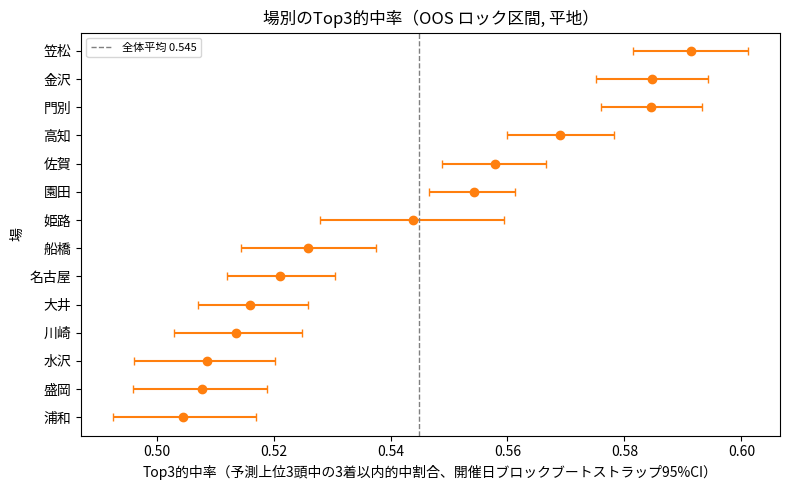

In [12]:
overall_top3_rate = flat_top3_scores["score"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
order3 = flat_top3.sort_values("top3_rate", ascending=False)
yerr3 = [order3["top3_rate"] - order3["ci_lo"], order3["ci_hi"] - order3["top3_rate"]]
ax.errorbar(order3["top3_rate"], order3["track"], xerr=yerr3, fmt="o", capsize=3, color="tab:orange")
ax.axvline(overall_top3_rate, color="gray", ls="--", lw=1, label=f"全体平均 {overall_top3_rate:.3f}")
ax.set_xlabel("Top3的中率（予測上位3頭中の3着以内的中割合、開催日ブロックブートストラップ95%CI）")
ax.set_ylabel("場")
ax.set_title("場別のTop3的中率（OOS ロック区間, 平地）")
ax.invert_yaxis()
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("track_top3_rate.png", dpi=120)
plt.show()


ばんえい（帯広ば）は §5 と同様、単独の値のみ報告し平地とは比較しない。

In [13]:
banei_top3_scores = top3_scores(banei, "ensemble")
banei_top3 = top3_rate_by_track(banei_top3_scores)
banei_top3.round(4)


,track,n_races,top3_rate,ci_lo,ci_hi
0,帯広ば,4425,0.4782,0.4703,0.4855


## 7. 結論と申し送り事項
- 平地全体の勝率（アンサンブル本命の1着的中率）は **35.68%**（35,059レース中12,510勝、
  95%CI [35.18%, 36.19%]）。個別モデルでは LightGBM 35.76%、TabM 35.64%、条件付きロジット
  33.97% で、アンサンブルは LightGBM/TabM とほぼ同水準（重み付けが主にこの2モデルに
  寄っているため、§2 冒頭の `nar.artifacts/oos_metrics.json` の weights とも整合）。
- 場別では **金沢 40.8%・佐賀 39.4%・高知 39.4%** が全体平均より明確に高く、
  **浦和 30.6%・水沢 30.6%・盛岡 32.6%・名古屋 33.2%** が明確に低い。BH補正
  （§3、14場で検定、FDR5%）後もこの7場は有意（`padj_bh` < 0.01）で、§4の開催日ブロック
  ブートストラップ CI も Wilson CI とほぼ一致するため、同日内相関で見かけ上有意になっている
  わけではない。
- ただし §1 の `avg_field_size` を見ると、勝率が高い場ほど平均頭数が少ない傾向がある
  （金沢 8.88頭・佐賀 10.25頭・高知 9.87頭 は中位以下、浦和 10.65頭・盛岡 10.06頭・
  名古屋 11.09頭は中位以上）。頭数が少ないレースは1着の的中確率が構造的に上がるため、
  この場間差の一部は「モデルの精度差」ではなく「頭数構成の違い」で説明できる可能性が高い。
  場の実力差を主張する前に、頭数で標準化した指標（例: 頭数帯別に層別した勝率、または
  `race_nll` のようなレース内相対指標）で追試するのが望ましい。
- ばんえい（帯広ば、§5）は単独で25.9%（4,425レース中1,147勝、95%CI [24.65%, 27.23%]）。
  平地13場のどの数値とも比較しない（[[banei-is-a-separate-model-family]]、
  出走頭数・モデル・オッズ体系が別物のため、同じ「勝率」欄に並べても意味を持たない）。
- **データの制約（再掲）**: `odds_win` / `popularity` がこの配布物の永続化予測に無いため、
  「市場の人気1番」を基準にした場別勝率の比較はできていない。次回配布物の評価から
  `odds_win` / `popularity` を残すよう `nar.eval.final_oos.evaluate` の出力列を見直すと、
  「モデルは市場よりどの場で強い/弱いか」まで踏み込める。
- OOS は施錠区間のため、本ノートブックは既存の永続化済み予測（開封記録は
  `artifacts/oos_access.log` / `artifacts/banei/oos_access.log`）を読むだけで、
  新たな開封（再評価）は行っていない。
